## **An Exploratory Data Analysis of the Adult Income (Census 1994) Dataset**
### Dataset: Adult Income (Census 1994)

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
import statsmodels.api as sm
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

#### **1. Data Preparation and Exploratory Data Analysis**

In [43]:
# 1. Load the Census Income dataset
# Direct URL to the data file
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Loading dataset, handling whitespace in CSV
census_data = pd.read_csv(url, names=columns, sep=',\s', engine='python')

print("Dataset Information:")
print(f"Shape(row, column): {census_data.shape}")
# Calculate baseline: percentage of people making >50K (taget variable)
high_income_rate = (census_data['income'] == '>50K').mean()
print(f"High Income Rate (>50K): {high_income_rate:.3f}")

Dataset Information:
Shape(row, column): (32561, 15)
High Income Rate (>50K): 0.241


In [44]:
census_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [45]:
print(census_data.info())
print(f"\nMissing Values per Column: \n{census_data.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None

Missing Values per Column: 
age               0
workclass         0
fnlwgt            0

In [46]:
census_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education-num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital-gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital-loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours-per-week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [47]:
#count the numerical columns
n_cols = census_data.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerical Columns: {n_cols.tolist()}")
print(f"Number of Numerical Columns: {len(n_cols)}")

Numerical Columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Number of Numerical Columns: 6


There are only six numerical columns, the other nine are non-numerical. The other columns can still be quantified through label encoding.

---

In [48]:
# 2. Data preprocessing
def preprocess_census_data(df):
    """Preprocessing for Census Income data"""
    df_processed = df.copy()
    
    # Handle missing values: UCI Census uses '?' for unknowns
    df_processed.replace('?', np.nan, inplace=True)
    
    # Simple imputation
    df_processed['workclass'].fillna(df_processed['workclass'].mode()[0], inplace=True)
    df_processed['occupation'].fillna(df_processed['occupation'].mode()[0], inplace=True)
    df_processed['native-country'].fillna(df_processed['native-country'].mode()[0], inplace=True)
    
    #Simplify Education: Grouping lowereducation levels together
    edu_map = {
        'Preschool': 'Dropout', '1st-4th': 'Dropout', '5th-6th': 'Dropout', '7th-8th': 'Dropout',
        '9th': 'Dropout', '10th': 'Dropout', '11th': 'Dropout', '12th': 'Dropout',
        'HS-grad': 'HS-grad', 'Some-college': 'College', 'Assoc-voc': 'College', 'Assoc-acdm': 'College',
        'Bachelors': 'Bachelors', 'Masters': 'Masters', 'Prof-school': 'Prof-school', 'Doctorate': 'Doctorate'
    }
    df_processed['education_simple'] = df_processed['education'].map(edu_map)
    
    # Feature engineering: Age groups
    df_processed['age_group'] = pd.cut(df_processed['age'], 
                                     bins=[0, 25, 45, 65, 100], 
                                     labels=['Young', 'Middle-Aged', 'Senior', 'Old'])
    
    return df_processed

# Apply preprocessing
census_processed = preprocess_census_data(census_data)
print("\nPreprocessed Dataset Information:")
print(f"Missing values after cleaning:\n{census_processed.isnull().sum()[census_processed.isnull().sum() > 0]}")


Preprocessed Dataset Information:
Missing values after cleaning:
Series([], dtype: int64)


---

In [49]:
# 3. Feature selection and Encoding
# note 'fnlwgt' is 'final weight'
def prepare_features(df):
    df_encoded = df.copy()
    
    # Target encoding
    le = LabelEncoder()
    y = le.fit_transform(df_encoded['income']) # >50K becomes 1, <=50K becomes 0
    
    # Select features (Mix of numerical and categorical)
    categorical_cols = ['workclass', 'education_simple', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'age_group']
    numerical_cols = ['fnlwgt', 'age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
    
    # Label Encoding for categorical columns to make them usable by Tree methods
    for col in categorical_cols:
        df_encoded[col + '_enc'] = le.fit_transform(df_encoded[col].astype(str))
    
    # Select final feature list
    feature_names = numerical_cols + [col + '_enc' for col in categorical_cols]
    X = df_encoded[feature_names]
    
    return X, y, feature_names

# Prepare data
X, y, feature_names = prepare_features(census_processed)

print(f"\nFeatures selected: {feature_names}")
print(f"Feature matrix shape: {X.shape}")


Features selected: ['fnlwgt', 'age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_enc', 'education_simple_enc', 'marital-status_enc', 'occupation_enc', 'relationship_enc', 'race_enc', 'sex_enc', 'native-country_enc', 'age_group_enc']
Feature matrix shape: (32561, 15)


Class Distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Proportions (%):
income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


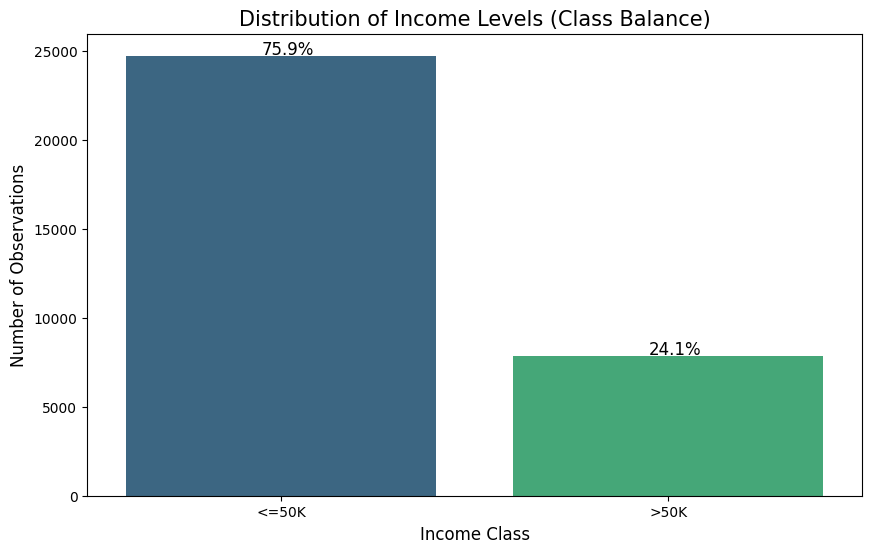

In [50]:
# Calculate counts and proportions
class_counts = census_data['income'].value_counts()
class_proportions = census_data['income'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(class_counts)
print("\nProportions (%):")
print(class_proportions)

# Visualization for distribution of target variable
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='income', data=census_data, palette='viridis')

# labels
plt.title('Distribution of Income Levels (Class Balance)', fontsize=15)
plt.xlabel('Income Class', fontsize=12)
plt.ylabel('Number of Observations', fontsize=12)

for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / len(census_data))
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 100
    ax.annotate(percentage, (x, y), size=12)

plt.show()

---

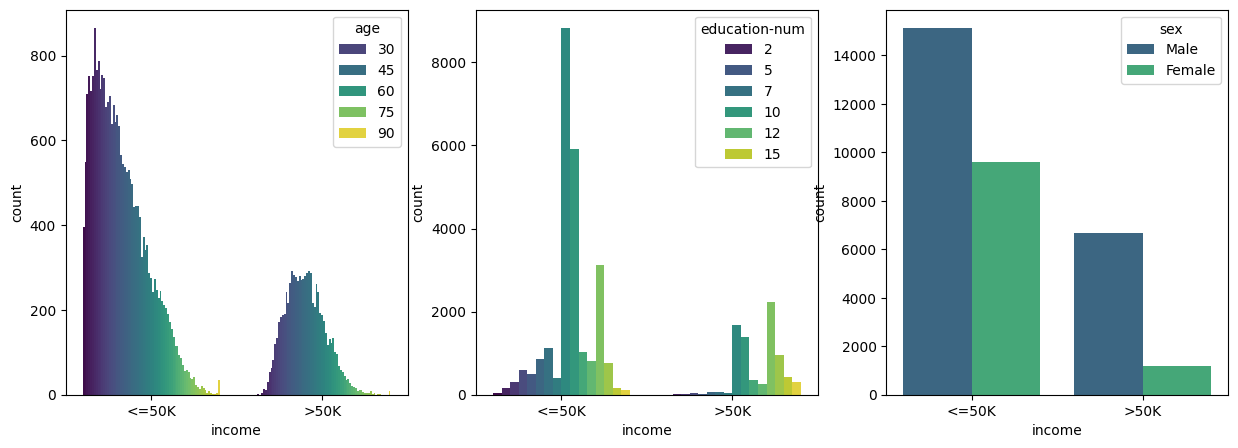

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(x='income', hue='age', data=census_data, palette='viridis', ax=axes[0])
sns.countplot(x='income', hue='education-num', data=census_data, palette='viridis', ax=axes[1])
sns.countplot(x='income', hue='sex', data=census_data, palette='viridis', ax=axes[2])
plt.show()

In [52]:
#compare number of men and women
print(census_data['sex'].value_counts())
print(f"\nDifference: {census_data['sex'].value_counts()[0] - census_data['sex'].value_counts()[1]}")

sex
Male      21790
Female    10771
Name: count, dtype: int64

Difference: 11019


The first graph (left) is on income and age. Apart from the already-mentioned class disparity between high and low income earners, there is also a disparity between people of age 30 who are high and low income, furthermore older people are present in both high and low income groups.

The second graph (middle) is on income and education-num, where the number corresponds to the years of education (2: 2nd grade). Years in education is not expected to scale linearly, as in comparing a 25 and 15 year old is not the same as comparing a 40 and 30 year old, younger people (especially below working age) are not expected to be making a lot of money, if any at all.

The third graph (right) compares the number of males and females from both classes; in both classes males clearly outnumber women. There are also more males part of the high income group. This graph implies there is another disparity between the subclass, sex, where females are underrepresented. We can confirm this in the cell below.

---

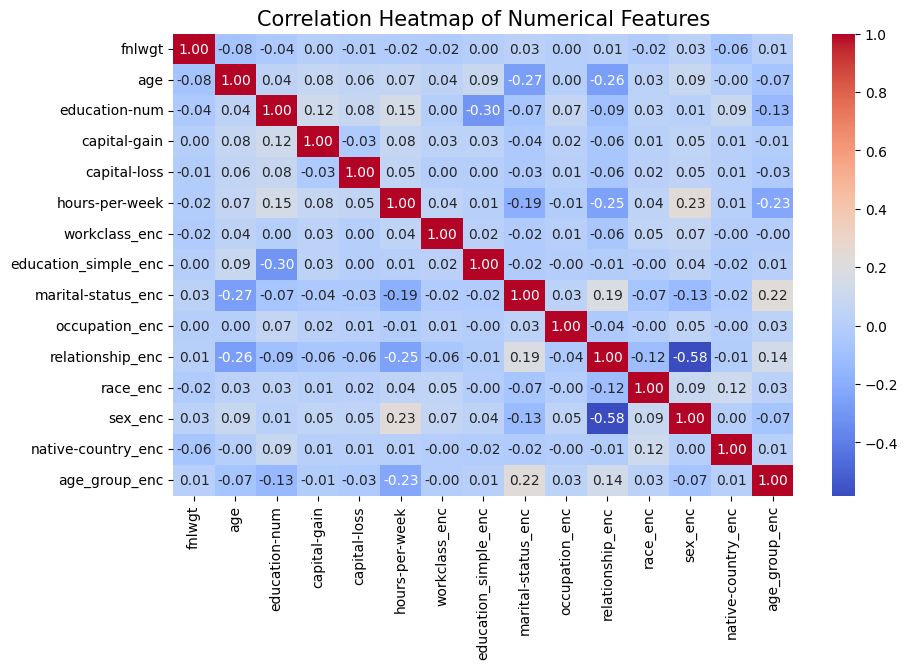

In [56]:
#heatmap of all numerical features
plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features', fontsize=15)
plt.show()

In [54]:
census_processed.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,education_simple,age_group
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,Bachelors,Middle-Aged
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Bachelors,Senior
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,HS-grad,Middle-Aged
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,Dropout,Senior
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,Bachelors,Middle-Aged


In [57]:
X.head()

,fnlwgt,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_enc,education_simple_enc,marital-status_enc,occupation_enc,relationship_enc,race_enc,sex_enc,native-country_enc,age_group_enc
0,77516,39,13,2174,0,40,6,0,4,0,1,4,1,38,0
1,83311,50,13,0,0,13,5,0,2,3,0,4,1,38,2
2,215646,38,9,0,0,40,3,4,0,5,1,4,1,38,0
3,234721,53,7,0,0,40,3,3,2,5,0,2,1,38,2
4,338409,28,13,0,0,40,3,0,2,9,5,2,0,4,0
